# Task 5: Mental Health Support Chatbot (Fine-Tuning Implementation)

**Objective**: Fine-tune a small LLM (DistilGPT2) using the `EmpatheticDialogues` dataset to provide supportive and empathetic responses.

### Step 1: Install and Import Dependencies

In [2]:
# Install necessary libraries (Uncomment if running for the first time)
# !pip install transformers datasets accelerate torch

from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, Trainer, TrainingArguments, default_data_collator ,EarlyStoppingCallback
import torch

### Step 2: Load and Preprocess the Dataset
The `empathetic_dialogues` dataset contains conversations. We will format these as: 
`<Context> User: [Input] Bot: [Response]` to teach the model how to reply.

In [4]:


# Load dataset (using full splits as requested)
dataset = load_dataset("Ahren09/empathetic_dialogues", split="train") 
val_dataset = load_dataset("Ahren09/empathetic_dialogues", split="validation")

# Load tokenizer
model_name = "distilgpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

def preprocess_function(examples):
    input_ids_list = []
    attention_mask_list = []
    labels_list = []

    # Mapping: 
    # 'context' is the emotion (sentimental, etc.)
    # 'prompt' is what the user actually said
    # 'utterance' is the empathetic response
    for context, user_msg, assistant_msg in zip(examples["context"], examples["prompt"], examples["utterance"]):
        
        # Format: Context -> User Input -> Assistant Response
        formatted_prompt = f"Context: {context}\nUser: {user_msg}\nAssistant:"
        full_text = f"{formatted_prompt} {assistant_msg}{tokenizer.eos_token}"

        tokenized = tokenizer(
            full_text,
            truncation=True,
            padding="max_length",
            max_length=128
        )

        input_ids = tokenized["input_ids"]
        attention_mask = tokenized["attention_mask"]
        labels = input_ids.copy()

        # Find where the response starts by tokenizing the prompt prefix
        tokenized_prompt = tokenizer(formatted_prompt, truncation=True, max_length=128)
        response_start_idx = len(tokenized_prompt["input_ids"])

        # Create Labels: 
        # 1. Mask the prompt (-100)
        # 2. Mask the padding (-100) based on attention_mask
        # 3. Keep the response tokens and the final EOS token
        for i in range(len(labels)):
            if i < response_start_idx or attention_mask[i] == 0:
                labels[i] = -100

        input_ids_list.append(input_ids)
        attention_mask_list.append(attention_mask)
        labels_list.append(labels)

    return {
        "input_ids": input_ids_list,
        "attention_mask": attention_mask_list,
        "labels": labels_list
    }

# Apply preprocessing
tokenized_train = dataset.map(
    preprocess_function,
    batched=True,
    remove_columns=dataset.column_names
)

tokenized_val = val_dataset.map(
    preprocess_function,
    batched=True,
    remove_columns=val_dataset.column_names
)

# ✅ Correct collator for pre-computed labels
data_collator = default_data_collator


Map:   0%|          | 0/84169 [00:00<?, ? examples/s]

Map:   0%|          | 0/6340 [00:00<?, ? examples/s]

### Step 3: Configure and Run Fine-Tuning
We use the `Trainer` API to handle the training loop. 
**Important**: Ensure GPU is enabled in Kaggle Settings.

In [5]:
!rm -rf /kaggle/working/mental_health_bot

In [6]:

# Load model
model = AutoModelForCausalLM.from_pretrained(model_name)

# 🔧 Dropout (helps overfitting)
model.config.resid_pdrop = 0.2
model.config.embd_pdrop = 0.2
model.config.attn_pdrop = 0.2


training_args = TrainingArguments(
    output_dir="./mental_health_bot",
    
    num_train_epochs=4,                  
    per_device_train_batch_size=2,
    gradient_accumulation_steps=2,
    
    eval_strategy="epoch",
    save_strategy="epoch",
    
    learning_rate=2e-5,
    weight_decay=0.01,
    
    logging_dir='./logs',
    fp16=True,
    
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    
    save_total_limit=2,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print("Starting Fine-tuning...")
trainer.train()
print("Training Complete!")

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


Training Complete!


### Step 3.1: Plot the Fine-Tuned Model
We create a matplotlib graphs to see how much optimized the model is.

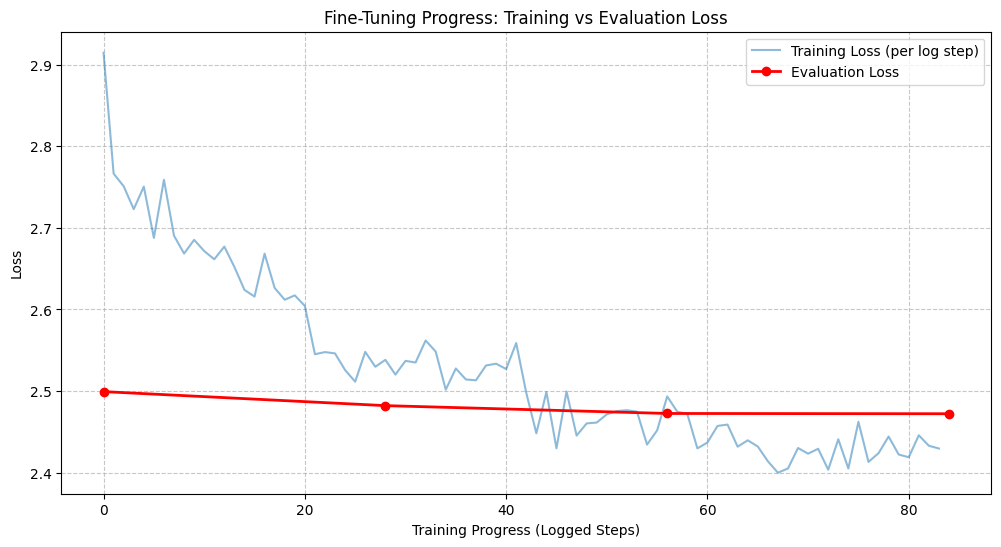


Final Evaluation Results: {'eval_loss': 2.472101926803589, 'eval_runtime': 37.486, 'eval_samples_per_second': 169.13, 'eval_steps_per_second': 10.591, 'epoch': 4.0}


In [7]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Extract the log history from the trainer
history = trainer.state.log_history

# 2. Parse logs for training and evaluation loss
train_loss = [log['loss'] for log in history if 'loss' in log]
eval_loss = [log['eval_loss'] for log in history if 'eval_loss' in log]
eval_epochs = [log['epoch'] for log in history if 'eval_loss' in log]

# 3. Create the plot
plt.figure(figsize=(12, 6))

# Plot Training Loss (logged every few steps)
if train_loss:
    plt.plot(train_loss, label='Training Loss (per log step)', alpha=0.5)

# Plot Evaluation Loss (logged every epoch)
if eval_loss:
    plt.plot(np.linspace(0, len(train_loss), len(eval_loss)), eval_loss, 
             label='Evaluation Loss', marker='o', color='red', linewidth=2)

plt.title('Fine-Tuning Progress: Training vs Evaluation Loss')
plt.xlabel('Training Progress (Logged Steps)')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 4. Final Evaluation on Validation Data
eval_results = trainer.evaluate()
print(f"\nFinal Evaluation Results: {eval_results}")


### Step 4: Test the Fine-Tuned Model
We create a generation function to see how the model responds to stress-related queries.

In [14]:
def generate_empathetic_response(user_input):
    prompt = f"Situation: {user_input} Response:"
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    
    # Generate text
    with torch.no_grad():
        output_tokens = model.generate(
                        **inputs, 
                        max_new_tokens=80,
                        do_sample=True, 
                        top_k=50, 
                        top_p=0.9, 
                        temperature=0.7,
                        repetition_penalty=1.2,     
                        no_repeat_ngram_size=3,     # prevents copying loops
                        pad_token_id=tokenizer.eos_token_id
                    )
    
    decoded = tokenizer.decode(output_tokens[0], skip_special_tokens=True)
    return decoded.split("Response:")[-1].strip()

test_input = "I am feeling very anxious about my final exams."
print(f"User: {test_input}")
print(f"Assisant: {generate_empathetic_response(test_input)}")

User: I am feeling very anxious about my final exams.
Assisant: I think I will pass!


### Step 5: Gradio Chat Interface

In [9]:
import gradio as gr

def chat_interface(message, history):
    bot_reply = generate_empathetic_response(message)
    return f"🌟 **Supportive Voice**\n\n{bot_reply}"

demo = gr.ChatInterface(
    fn=chat_interface,
    title="Empathetic Mental Wellness Bot",
    description="A chatbot fine-tuned on empathetic dialogues to support your well-being.",
    theme="soft"
)

demo.launch(share=True)

/usr/local/lib/python3.12/dist-packages/gradio/chat_interface.py:347: UserWarning: The 'tuples' format for chatbot messages is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style 'role' and 'content' keys.
  self.chatbot = Chatbot(


* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://cd5e37ec5a0c257eac.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
